In [21]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

# Settings to keep the notebook clean
warnings.filterwarnings('ignore')
%matplotlib inline

# Absolute path to your dataset
path = r"C:\Users\swetha mehtre\Desktop\project3\DataCoSupplyChainDataset.csv"

try:
    # Loading the data with 'latin1' encoding to handle special characters
    df = pd.read_csv(path, encoding='latin1')
    print("--- SUCCESS: Dataset Loaded ---")
    print(f"Total Records: {df.shape[0]}")
    print(f"Total Columns: {df.shape[1]}")
    
    # Standardizing Column Names immediately (makes coding easier)
    df.columns = [col.lower().replace(' ', '_').replace('(', '').replace(')', '') for col in df.columns]
    print("Columns standardized: Spaces replaced with underscores.")
    
    # Preview the first 3 rows
    display(df.head(15))
except Exception as e:
    print(f"--- ERROR: Could not load file ---\n{e}")

--- SUCCESS: Dataset Loaded ---
Total Records: 180519
Total Columns: 53
Columns standardized: Spaces replaced with underscores.


,type,days_for_shipping_real,days_for_shipment_scheduled,benefit_per_order,sales_per_customer,delivery_status,late_delivery_risk,category_id,category_name,customer_city,...,order_zipcode,product_card_id,product_category_id,product_description,product_image,product_name,product_price,product_status,shipping_date_dateorders,shipping_mode
0,DEBIT,3,4,91.250000,314.640015,Advance shipping,0,73,Sporting Goods,Caguas,...,NaN,1360,73,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,0,2/3/2018 22:56,Standard Class
1,TRANSFER,5,4,-249.089996,311.359985,Late delivery,1,73,Sporting Goods,Caguas,...,NaN,1360,73,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,0,1/18/2018 12:27,Standard Class
2,CASH,4,4,-247.779999,309.720001,Shipping on time,0,73,Sporting Goods,San Jose,...,NaN,1360,73,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,0,1/17/2018 12:06,Standard Class
3,DEBIT,3,4,22.860001,304.809998,Advance shipping,0,73,Sporting Goods,Los Angeles,...,NaN,1360,73,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,0,1/16/2018 11:45,Standard Class
4,PAYMENT,2,4,134.210007,298.250000,Advance shipping,0,73,Sporting Goods,Caguas,...,NaN,1360,73,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,0,1/15/2018 11:24,Standard Class
5,TRANSFER,6,4,18.580000,294.980011,Shipping canceled,0,73,Sporting Goods,Tonawanda,...,NaN,1360,73,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,0,1/19/2018 11:03,Standard Class
6,DEBIT,2,1,95.180000,288.420013,Late delivery,1,73,Sporting Goods,Caguas,...,NaN,1360,73,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,0,1/15/2018 10:42,First Class
7,TRANSFER,2,1,68.430000,285.140015,Late delivery,1,73,Sporting Goods,Miami,...,NaN,1360,73,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,0,1/15/2018 10:21,First Class
8,CASH,3,2,133.720001,278.589996,Late delivery,1,73,Sporting Goods,Caguas,...,NaN,1360,73,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,0,1/16/2018 10:00,Second Class
9,CASH,2,1,132.149994,275.309998,Late delivery,1,73,Sporting Goods,San Ramon,...,NaN,1360,73,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,0,1/15/2018 9:39,First Class


In [8]:
# 1. Create a boolean flag for late deliveries
# This turns the text "Late delivery" into a True/False value we can calculate
df['is_late'] = df['delivery_status'] == 'Late delivery'

# 2. Calculate the 'Shipping Gap'
# Formula: Actual Days - Scheduled Days
# If the result is 2, the order was 2 days later than promised.
df['shipping_gap'] = df['days_for_shipping_real'] - df['days_for_shipment_scheduled']

# 3. Calculate key summary statistics to verify the data
late_percent = df['is_late'].mean() * 100
avg_gap = df['shipping_gap'].mean()

print(f"--- Step 2: Metrics Created ---")
print(f"Overall Late Delivery Rate: {late_percent:.2f}%")
print(f"Average Delay per Order: {avg_gap:.2f} days")

# Preview the specific columns we just built
df[['delivery_status', 'is_late', 'shipping_gap', 'days_for_shipping_real', 'days_for_shipment_scheduled']].head()

--- Step 2: Metrics Created ---
Overall Late Delivery Rate: 54.83%
Average Delay per Order: 0.57 days


,delivery_status,is_late,shipping_gap,days_for_shipping_real,days_for_shipment_scheduled
0,Advance shipping,False,-1,3,4
1,Late delivery,True,1,5,4
2,Shipping on time,False,0,4,4
3,Advance shipping,False,-1,3,4
4,Advance shipping,False,-2,2,4


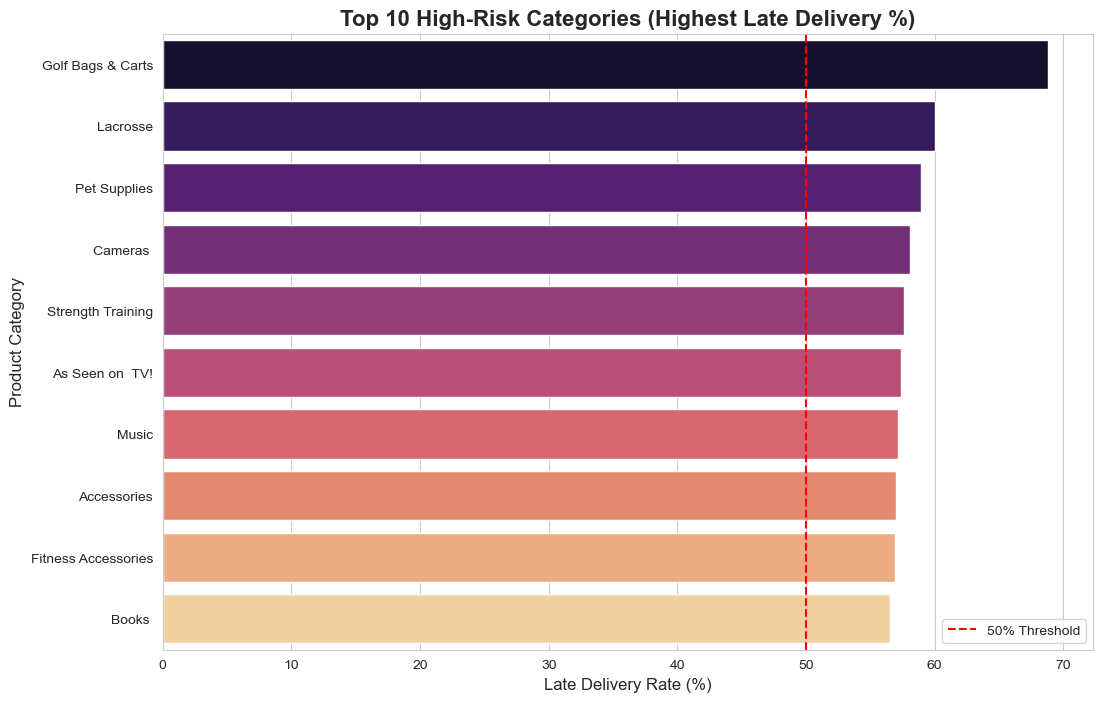

In [9]:
# 1. Group by Category and calculate the percentage of late orders
category_late_rate = df.groupby('category_name')['is_late'].mean().sort_values(ascending=False).head(10) * 100

# 2. Set up the plotting area
plt.figure(figsize=(12, 8))
sns.set_style("whitegrid")

# 3. Create the Bar Chart
sns.barplot(x=category_late_rate.values, y=category_late_rate.index, palette='magma')

# 4. Add labels and a "danger zone" line
plt.title('Top 10 High-Risk Categories (Highest Late Delivery %)', fontsize=16, fontweight='bold')
plt.xlabel('Late Delivery Rate (%)', fontsize=12)
plt.ylabel('Product Category', fontsize=12)
plt.axvline(x=50, color='red', linestyle='--', label='50% Threshold')
plt.legend()

plt.show()

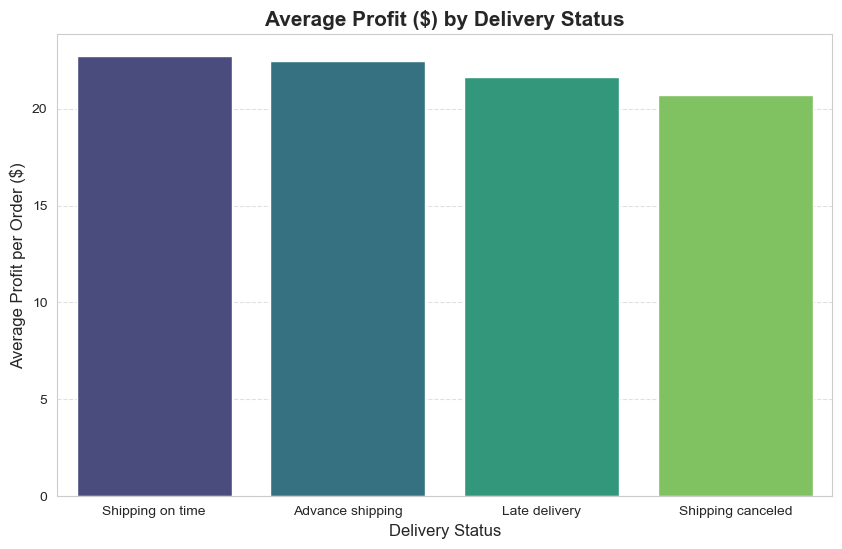

Average Profit per Order Status:
     delivery_status  benefit_per_order
0   Shipping on time          22.709146
1   Advance shipping          22.485701
2      Late delivery          21.621707
3  Shipping canceled          20.696717


In [10]:
# 1. Group by Delivery Status and calculate the average profit
profit_analysis = df.groupby('delivery_status')['benefit_per_order'].mean().sort_values(ascending=False).reset_index()

# 2. Set up the plotting area
plt.figure(figsize=(10, 6))

# 3. Create the Bar Chart
sns.barplot(data=profit_analysis, x='delivery_status', y='benefit_per_order', palette='viridis')

# 4. Add formatting and labels
plt.title('Average Profit ($) by Delivery Status', fontsize=15, fontweight='bold')
plt.xlabel('Delivery Status', fontsize=12)
plt.ylabel('Average Profit per Order ($)', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.6)

plt.show()

# Print the exact numbers for the report
print("Average Profit per Order Status:")
print(profit_analysis)

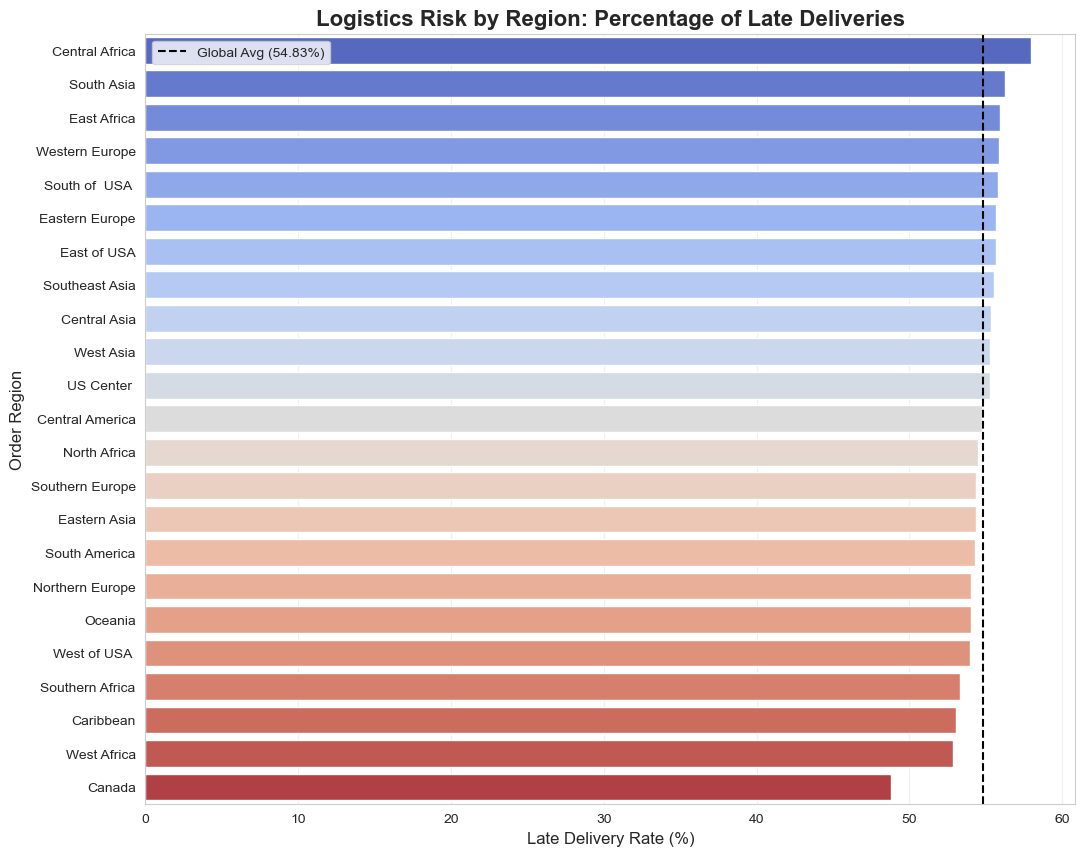

Top 5 Regions with Highest Delivery Risk:
     order_region    is_late
0  Central Africa  57.960644
1      South Asia  56.266977
2     East Africa  55.939525
3  Western Europe  55.848611
4  South of  USA   55.772559


In [11]:
# 1. Calculate the Late Delivery Rate by Region
region_risk = df.groupby('order_region')['is_late'].mean().sort_values(ascending=False).reset_index()
region_risk['is_late'] = region_risk['is_late'] * 100  # Convert to percentage

# 2. Set up the plotting area
plt.figure(figsize=(12, 10))

# 3. Create a horizontal bar chart for better readability of region names
sns.barplot(data=region_risk, x='is_late', y='order_region', palette='coolwarm')

# 4. Add a vertical line for the global average (calculated in Step 2)
plt.axvline(x=54.83, color='black', linestyle='--', label='Global Avg (54.83%)')

# 5. Styling
plt.title('Logistics Risk by Region: Percentage of Late Deliveries', fontsize=16, fontweight='bold')
plt.xlabel('Late Delivery Rate (%)', fontsize=12)
plt.ylabel('Order Region', fontsize=12)
plt.legend()
plt.grid(axis='x', alpha=0.3)

plt.show()

# Print the top 5 most problematic regions
print("Top 5 Regions with Highest Delivery Risk:")
print(region_risk.head(5))

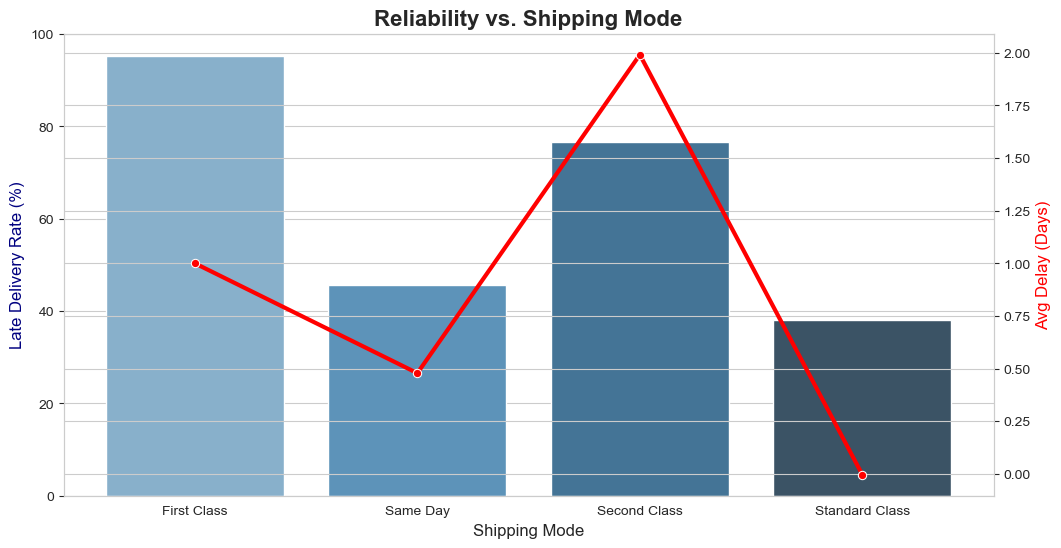

Shipping Mode Performance Summary:
    shipping_mode  late_rate_%  shipping_gap
0     First Class    95.322499      1.000000
2    Second Class    76.632781      1.990828
1        Same Day    45.743042      0.478279
3  Standard Class    38.071683     -0.004093


In [12]:
# 1. Calculate Late Rate and Average Delay for each Shipping Mode
ship_mode_analysis = df.groupby('shipping_mode').agg({
    'is_late': 'mean',
    'shipping_gap': 'mean'
}).reset_index()

# Convert late rate to percentage
ship_mode_analysis['late_rate_%'] = ship_mode_analysis['is_late'] * 100

# 2. Visualize the results
fig, ax1 = plt.subplots(figsize=(12, 6))

# Plot the Late Rate as a Bar Chart
sns.barplot(data=ship_mode_analysis, x='shipping_mode', y='late_rate_%', ax=ax1, palette='Blues_d')
ax1.set_ylabel('Late Delivery Rate (%)', fontsize=12, color='navy')
ax1.set_xlabel('Shipping Mode', fontsize=12)
ax1.set_title('Reliability vs. Shipping Mode', fontsize=16, fontweight='bold')

# Add a twin axis to show the average delay in days as a line
ax2 = ax1.twinx()
sns.lineplot(data=ship_mode_analysis, x='shipping_mode', y='shipping_gap', ax=ax2, color='red', marker='o', linewidth=3)
ax2.set_ylabel('Avg Delay (Days)', fontsize=12, color='red')

plt.show()

# Display the summary table
print("Shipping Mode Performance Summary:")
print(ship_mode_analysis[['shipping_mode', 'late_rate_%', 'shipping_gap']].sort_values(by='late_rate_%', ascending=False))

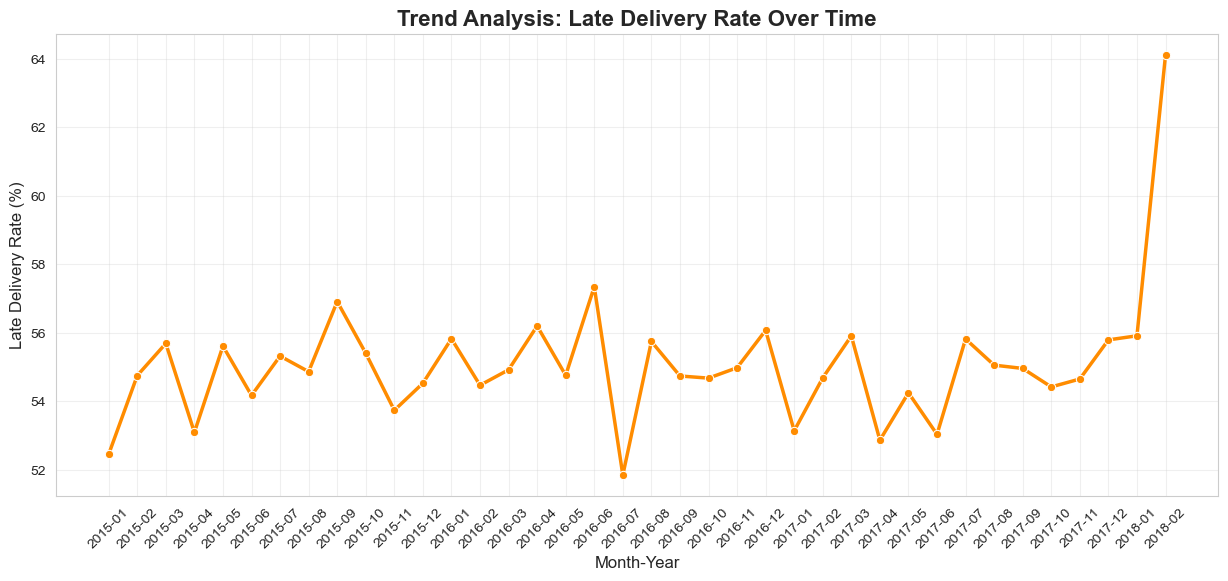

Timeline Analysis Complete.


In [13]:
# 1. Convert the shipping date to a Python Datetime object
df['shipping_date_dateorders'] = pd.to_datetime(df['shipping_date_dateorders'])

# 2. Extract Year and Month for grouping
df['order_month_year'] = df['shipping_date_dateorders'].dt.to_period('M').astype(str)

# 3. Calculate the Monthly Late Rate
timeline_analysis = df.groupby('order_month_year')['is_late'].mean().reset_index()
timeline_analysis['late_rate_%'] = timeline_analysis['is_late'] * 100

# 4. Visualize the Timeline
plt.figure(figsize=(15, 6))
sns.lineplot(data=timeline_analysis, x='order_month_year', y='late_rate_%', marker='o', color='darkorange', linewidth=2.5)

# 5. Styling
plt.title('Trend Analysis: Late Delivery Rate Over Time', fontsize=16, fontweight='bold')
plt.xlabel('Month-Year', fontsize=12)
plt.ylabel('Late Delivery Rate (%)', fontsize=12)
plt.xticks(rotation=45) # Rotate dates so they don't overlap
plt.grid(True, alpha=0.3)

plt.show()

print("Timeline Analysis Complete.")

Training the model... please wait.

--- Model Performance Report ---
              precision    recall  f1-score   support

       False       0.61      0.87      0.72     16307
        True       0.84      0.54      0.66     19797

    accuracy                           0.69     36104
   macro avg       0.72      0.71      0.69     36104
weighted avg       0.73      0.69      0.69     36104



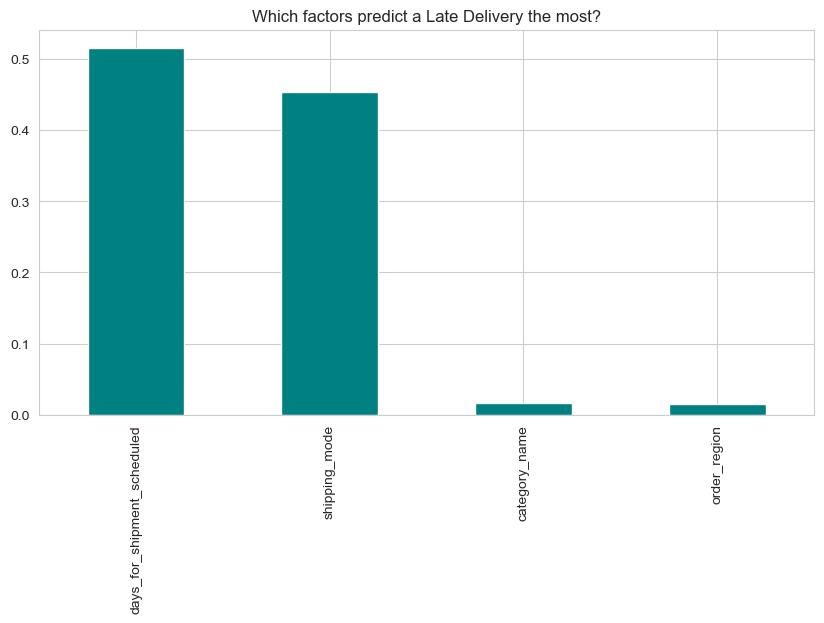

In [14]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.preprocessing import LabelEncoder

# 1. Feature Selection: Choosing variables that might predict lateness
# We use category, region, shipping mode, and the scheduled days
features = ['category_name', 'order_region', 'shipping_mode', 'days_for_shipment_scheduled']
X = df[features].copy()
y = df['is_late']

# 2. Encoding: Convert text data into numbers so the model can understand it
le = LabelEncoder()
for col in ['category_name', 'order_region', 'shipping_mode']:
    X[col] = le.fit_transform(X[col])

# 3. Splitting: 80% to train the model, 20% to test it
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 4. Training: Building the Random Forest model
print("Training the model... please wait.")
model = RandomForestClassifier(n_estimators=100, max_depth=10, random_state=42)
model.fit(X_train, y_train)

# 5. Evaluation: See how well we did
y_pred = model.predict(X_test)

print("\n--- Model Performance Report ---")
print(classification_report(y_test, y_pred))

# 6. Feature Importance: Which factor matters most?
importance = pd.Series(model.feature_importances_, index=features).sort_values(ascending=False)
plt.figure(figsize=(10, 5))
importance.plot(kind='bar', color='teal')
plt.title('Which factors predict a Late Delivery the most?')
plt.show()

In [15]:
# 1. Select only the columns that are useful for a Dashboard
cols_for_dashboard = [
    'type', 'days_for_shipping_real', 'days_for_shipment_scheduled', 
    'benefit_per_order', 'sales_per_customer', 'delivery_status', 
    'category_name', 'customer_city', 'order_region', 'order_country',
    'is_late', 'shipping_gap', 'shipping_mode', 'order_month_year'
]

df_dashboard = df[cols_for_dashboard]

# 2. Save to a new CSV file
# This file will be saved in the same folder as your notebook
output_path = "Supply_Chain_Analysis_Final.csv"
df_dashboard.to_csv(output_path, index=False)

print(f"--- PROJECT COMPLETE ---")
print(f"Your cleaned dataset has been saved as: {output_path}")
print(f"Final file size is much smaller and ready for Power BI/Tableau.")

--- PROJECT COMPLETE ---
Your cleaned dataset has been saved as: Supply_Chain_Analysis_Final.csv
Final file size is much smaller and ready for Power BI/Tableau.


In [20]:
import panel as pn
import plotly.express as px
import plotly.graph_objects as go

pn.extension('plotly')

# 1. Dashboard Title
title = pn.pane.Markdown("# 🚚 Supply Chain Executive Dashboard", styles={'font-size': '24pt', 'color': '#2c3e50'})

# 2. KPI Cards Function
def create_kpi(label, value, color):
    return pn.indicators.Number(
        name=label, value=value, format='{value}',
        colors=[(value, color)], font_size='20pt', title_size='12pt'
    )

# Calculate KPIs
total_orders = len(df)
late_rate = round(df['is_late'].mean() * 100, 1)
total_profit = round(df['benefit_per_order'].sum() / 1000000, 2)
avg_delay = round(df['shipping_gap'].mean(), 2)

kpis = pn.Row(
    create_kpi("Total Orders", total_orders, "#2980b9"),
    create_kpi("Late Delivery %", late_rate, "#e74c3c"),
    create_kpi("Total Profit ($M)", total_profit, "#27ae60"),
    create_kpi("Avg Delay (Days)", avg_delay, "#f39c12"),
    sizing_mode='stretch_width'
)

# 3. Visuals
# A. Monthly Trend
fig_trend = px.line(df.groupby('order_month_year')['benefit_per_order'].sum().reset_index(), 
                    x='order_month_year', y='benefit_per_order', 
                    title="Profit Trends by Month", template="plotly_white")
fig_trend.update_traces(line_color='#2ecc71')

# B. Category Risk (Top 10)
cat_data = df.groupby('category_name')['is_late'].mean().nlargest(10).reset_index()
cat_data['is_late'] = cat_data['is_late'] * 100
fig_cat = px.bar(cat_data, x='is_late', y='category_name', orientation='h', 
                 title="Top 10 High-Risk Categories (%)", color='is_late', 
                 color_continuous_scale='Reds', template="plotly_white")

# C. Region Distribution
region_data = df.groupby('order_region')['sales_per_customer'].sum().reset_index()
fig_region = px.pie(region_data, values='sales_per_customer', names='order_region', 
                    title="Sales Distribution by Region", hole=0.4)

# 4. Layout (Fixed: Using styles instead of background)
dashboard = pn.Column(
    title,
    kpis,
    pn.Row(pn.pane.Plotly(fig_trend, sizing_mode='stretch_width'), 
           pn.pane.Plotly(fig_region, sizing_mode='stretch_width')),
    pn.pane.Plotly(fig_cat, sizing_mode='stretch_width'),
    sizing_mode='stretch_width',
    styles={'background': '#f8f9fa', 'padding': '15px'} 
)

# Display the Dashboard
dashboard

Column(sizing_mode='stretch_width', styles={'background': '#f8f9fa', ...})
    [0] Markdown(str, styles={'font-size': '24pt', ...})
    [1] Row(sizing_mode='stretch_width')
        [0] Number(colors=[(180519, '#2980b9')], font_size='20pt', name='Total Orders', title_size='12pt', value=180519)
        [1] Number(colors=[(np.float64(54.8), ...], font_size='20pt', name='Late Delivery %', title_size='12pt', value=np.float64(54.8))
        [2] Number(colors=[(np.float64(3.97), ...], font_size='20pt', name='Total Profit ($M)', title_size='12pt', value=np.float64(3.97))
        [3] Number(colors=[(np.float64(0.57), ...], font_size='20pt', name='Avg Delay (Days)', title_size='12pt', value=np.float64(0.57))
    [2] Row
        [0] Plotly(Figure, sizing_mode='stretch_width')
        [1] Plotly(Figure, sizing_mode='stretch_width')
    [3] Plotly(Figure, sizing_mode='stretch_width')